### **BESS Dispatch Optimisation**

#### **What this notebook does**

I use the intra-day price forecasts produced in the previous notebook to optimise the dispatch of a Battery Energy Storage System (BESS) i.e. deciding, for each hour, when to charge and discharge to maximise revenue. 

We base the battery specs on **Engie's Cathkin BESS** (East Kilbride, Scotland), Engie's first UK battery acquisition.

#### **Why**

A battery makes money through **time arbitrage**: 
- buy electricity when it's cheap *(typically at night)*
- sell it when it's expensive *(typically the evening peak)*. 

But it has physical limits *(capacity, power, and round-trip efficiency losses)* so the strategy is not obvious. And it must decide **in advance**, using only **forecasted** prices, never the true future ones.

This closes the loop on the project: the forecast isn't the end goal in itself it's an input to a **decision**, it could have been part of a trading strategy aimed at generating P&L in order to generate PnL, but I'm more focused on making the world a better place...

#### **How**

We frame it as a **linear optimisation** problem and solve it with **PuLP**:
- **Decision variables** : how much to charge / discharge / store each hour
- **Objective** : maximise total revenue over the day
- **Constraints** : capacity, power, efficiency, and the daily energy balance

We then benchmark the optimised strategy against a simple **naive rule** to measure the value the optimisation actually adds.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pulp

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)

#### **Load forecasts**

In [5]:
# Load the forecasts exported

forecast_df = pd.read_csv('dataset/forecast_ID_2024.csv', parse_dates=['timestamp'])
print(forecast_df.shape)
forecast_df.head()

(8784, 2)


,timestamp,price_forecast
0,2024-01-01 00:00:00,46.010020
1,2024-01-01 01:00:00,43.455105
2,2024-01-01 02:00:00,21.119822
3,2024-01-01 03:00:00,6.853328
4,2024-01-01 04:00:00,6.649598


#### **Extract one day**

Why a single day?
A battery operates on a daily cycle: it charges and discharges within the day. The brief even requires it to end the day at the same level it started `(final_soc = initial_soc)`. So the natural optimisation unit is 24h.

Why 14 October specifically? I picked the day of the big price spike because a large price swing within the day = more arbitrage opportunity = a more illustrative example. But we can take any day (and we will using a superb streamlit dashboard).

In [6]:
# Pick one day to optimise the battery on
day = '2024-10-14'

day_data = forecast_df[forecast_df['timestamp'].dt.date == pd.Timestamp(day).date()]
forecasted_prices = day_data.sort_values('timestamp')['price_forecast'].values

print(f"Day: {day} | {len(forecasted_prices)} periods")
print(forecasted_prices.round(1))

Day: 2024-10-14 | 24 periods
[ 78.8  79.2  74.5  80.4  94.5 103.9 120.9 116.8 115.3 105.1  95.3  88.4
  94.   92.6 105.1 134.7 171.4 178.2 134.2 103.2  91.8  86.1  91.5  87.6]


#### **Battery parameters & problem setup**

*"Our second BESS project is a 50 MW, 2-hour duration battery storage site in Cathkin" - https://www.engie.co.uk/power-storage/bess/*

In [7]:
# Battery specs
capacity_mwh = 100 # 50 MW * 2h
power_mw     = 50  
efficiency   = 0.90 # Standard LFP industry assumption (according to claude)
initial_soc  = 0.5 * capacity_mwh   # starts half full
final_soc    = 0.5 * capacity_mwh   # must end half full

period_hours = 1.0
max_energy_per_period = power_mw * period_hours   # 50 MWh max per hour

n = len(forecasted_prices)

# Create the optimisation problem (we want to MAXIMISE revenue)
prob = pulp.LpProblem("BESS_dispatch", pulp.LpMaximize)

#### **Decision Variables**

For each period `t`, the optimiser decides three quantities:

- **`charge[t]`** : energy charged during hour `t`, between 0 and `max_energy_per_period` (50 MWh)
- **`discharge[t]`** : energy discharged during hour `t`, between 0 and `max_energy_per_period` (50 MWh)
- **`soc[t]`** : state of charge (energy stored) at the end of hour `t`, between 0 and `capacity_mwh` (100 MWh)

The bounds (`lowBound` / `upBound`) already encode two physical constraints: we can't exchange more than the maximum power per hour, nor store more than the battery's capacity.

In [8]:
charge = [pulp.LpVariable(f"charge_{t}", lowBound=0, upBound=max_energy_per_period) for t in range(n)]

discharge = [pulp.LpVariable(f"discharge_{t}", lowBound=0, upBound=max_energy_per_period) for t in range(n)]

soc = [pulp.LpVariable(f"soc_{t}", lowBound=0, upBound=capacity_mwh) for t in range(n)]

#### **Objective function (revenue to maximise)**

This is the heart of the problem — what PuLP tries to **maximise**:

- `forecasted_prices[t] * discharge[t]` : money **earned** by selling at hour `t` (price × energy sold)
- `forecasted_prices[t] * charge[t]` : money **spent** buying at hour `t`
- We subtract the two, and `lpSum` adds it up over all 24 hours : the **total daily revenue**

`prob += ...` adds this expression to the problem. Since we declared `LpMaximize`, PuLP searches for the `charge` / `discharge` values that make this sum as large as possible.

In [9]:
# Revenue = money from selling (discharge) minus money spent buying (charge), summed over all hours
prob += pulp.lpSum(
    forecasted_prices[t] * discharge[t] - forecasted_prices[t] * charge[t]
    for t in range(n)
)

#### **Core constraints (energy balance)**

This is the battery's **energy conservation law**, hour by hour:

- `soc[t-1]` : what was stored before
- `+ charge[t] * efficiency` : what we add by charging. **This is where efficiency is applied**: if we buy 10 MWh, only 9 actually enter the battery (the 90%)
- `- discharge[t]` : what we remove by discharging

For the **first hour** (`t == 0`), there is no `soc[t-1]`, so we start from `initial_soc` (the battery half full).

The last line forces the battery to **end at its starting level** (`final_soc`) — the fairness constraint discussed earlier.

In [10]:
for t in range(n):
    if t == 0:
        # First hour: start from the initial state of charge
        prob += soc[t] == initial_soc + charge[t] * efficiency - discharge[t]
    else:
        # Each hour: previous level + what we charged (minus losses) - what we discharged
        prob += soc[t] == soc[t-1] + charge[t] * efficiency - discharge[t]

# The battery must end the day at the required final level
prob += soc[n-1] == final_soc

#### **Solve the problem & Extract the optimal schedule**

In [11]:
# Runs the solver (CBC, shipped with PulP), msg=0 hides technical log
prob.solve(pulp.PULP_CBC_CMD(msg=0))

# Check the solver found an optimal solution
print("Status:", pulp.LpStatus[prob.status])

# Total revenue = the value of the objective we maximised
total_revenue = pulp.value(prob.objective)
print(f"Total revenue: £{total_revenue:,.2f}")

# Sanity check: confirm no hour charges AND discharges at the same time - Used AI here
simultaneous = [t for t in range(n) if charge[t].value() > 1e-6 and discharge[t].value() > 1e-6]
print("Periods charging AND discharging:", simultaneous)   # should be []

Status: Optimal
Total revenue: £10,318.05
Periods charging AND discharging: []


In [12]:
# Pull the solved values into a tidy dataframe, one row per hour
schedule = pd.DataFrame({
    'hour': range(n),
    'price': forecasted_prices,
    'charge': [charge[t].value() for t in range(n)],
    'discharge': [discharge[t].value() for t in range(n)],
    'soc': [soc[t].value() for t in range(n)],
})

schedule.round(2)

,hour,price,charge,discharge,soc
0,0,78.77,5.56,0.0,55.0
1,1,79.16,0.00,0.0,55.0
2,2,74.53,50.00,0.0,100.0
3,3,80.42,0.00,0.0,100.0
4,4,94.54,0.00,0.0,100.0
5,5,103.86,0.00,0.0,100.0
6,6,120.94,0.00,50.0,50.0
7,7,116.83,0.00,50.0,0.0
8,8,115.27,0.00,0.0,0.0
9,9,105.12,0.00,0.0,0.0


The optimiser runs **two arbitrage cycles** over the day, buying low and selling high:

- **Cycle 1 (morning):** charges overnight at the cheapest hours (h0 at £78.8, h2 at £74.5 — the daily low) and discharges at h6–h7 (£121, £117).
- **Cycle 2 (evening):** recharges midday (h11–h13, ~£88–94) and discharges at h16–h17 (£171, £178 — the evening peak).
- **End of day:** a final recharge at h21–h23 brings the battery back to 50% SOC. This is driven by the `final_soc` constraint, not by profit.

The behaviour matches the economic intuition: the battery exploits **both price humps** rather than waiting only for the evening peak, because its limited capacity and power make multiple smaller cycles more valuable than a single one. The state of charge stays within [0, 100] MWh at all times, and the battery ends exactly where it started (50%), as required.


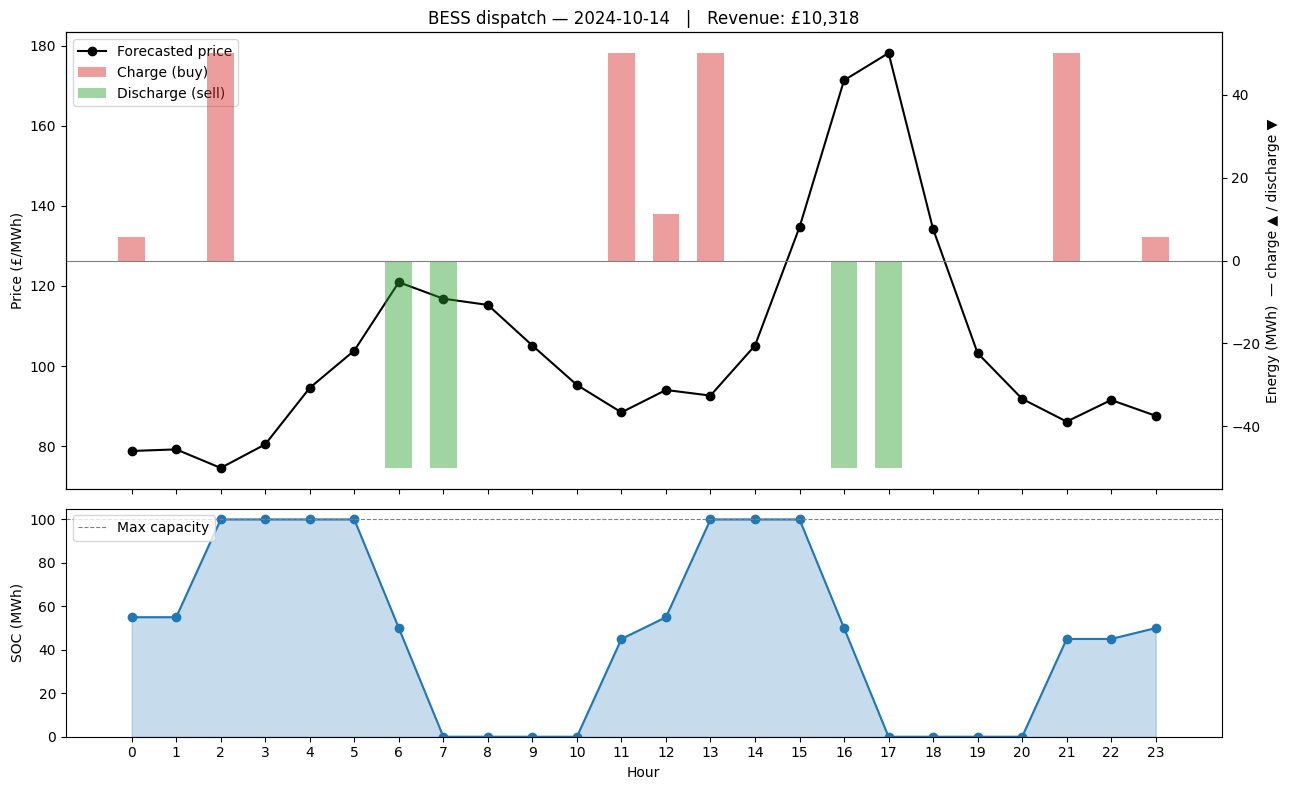

Total revenue        : £10,318.05
Energy bought        : 222.2 MWh  (avg £85.7/MWh)
Energy sold          : 200.0 MWh  (avg £146.8/MWh)
Equivalent cycles    : 2.00


In [ ]:
# Made with AI

def plot_dispatch(schedule, total_revenue, day, capacity_mwh):
    hours = schedule['hour']

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                                   gridspec_kw={'height_ratios': [2, 1]})

    # --- Panel 1: forecasted price + charge/discharge actions ---
    ax1.plot(hours, schedule['price'], color='black', marker='o', zorder=3, label='Forecasted price')
    ax1.set_ylabel('Price (£/MWh)')
    ax1.set_title(f'BESS dispatch — {day}   |   Revenue: £{total_revenue:,.0f}')

    # Second y-axis for energy bars: charge = into battery (up), discharge = out (down)
    ax1b = ax1.twinx()
    ax1b.bar(hours,  schedule['charge'],    width=0.6, color='tab:red',   alpha=0.45, label='Charge (buy)')
    ax1b.bar(hours, -schedule['discharge'], width=0.6, color='tab:green', alpha=0.45, label='Discharge (sell)')
    ax1b.axhline(0, color='grey', linewidth=0.8)
    ax1b.set_ylabel('Energy (MWh)  — charge ▲ / discharge ▼')

    # Merge the two legends into one
    l1, lab1 = ax1.get_legend_handles_labels()
    l2, lab2 = ax1b.get_legend_handles_labels()
    ax1.legend(l1 + l2, lab1 + lab2, loc='upper left')

    # --- Panel 2: state of charge over the day ---
    ax2.fill_between(hours, schedule['soc'], color='tab:blue', alpha=0.25)
    ax2.plot(hours, schedule['soc'], color='tab:blue', marker='o')
    ax2.axhline(capacity_mwh, color='grey', linestyle='--', linewidth=0.8, label='Max capacity')
    ax2.set_ylabel('SOC (MWh)')
    ax2.set_xlabel('Hour')
    ax2.set_ylim(0, capacity_mwh * 1.05)
    ax2.set_xticks(hours)
    ax2.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

    # --- Useful summary ---
    energy_charged    = schedule['charge'].sum()
    energy_discharged = schedule['discharge'].sum()
    cycles            = energy_discharged / capacity_mwh
    avg_buy  = (schedule['price'] * schedule['charge']).sum()    / energy_charged
    avg_sell = (schedule['price'] * schedule['discharge']).sum() / energy_discharged

    print(f"Total revenue        : £{total_revenue:,.2f}")
    print(f"Energy bought        : {energy_charged:,.1f} MWh  (avg £{avg_buy:.1f}/MWh)")
    print(f"Energy sold          : {energy_discharged:,.1f} MWh  (avg £{avg_sell:.1f}/MWh)")
    print(f"Equivalent cycles    : {cycles:.2f}")

plot_dispatch(schedule, total_revenue, day, capacity_mwh)